In [23]:
GPT_CONFIG_124M = {
    "vocab_size": 50257, #Vocabulary Size
    "context_length": 1024, #Context Length
    "emb_dim":768, #Embedding Dimension
    "n_heads": 12, #Number of Attention Heads
    "n_layers": 12, #Number of Transformer Layer
    "drop_rate": 0.1, #Drop out rate
    "qkv_bias": False #Query-Key_Value Bias
}

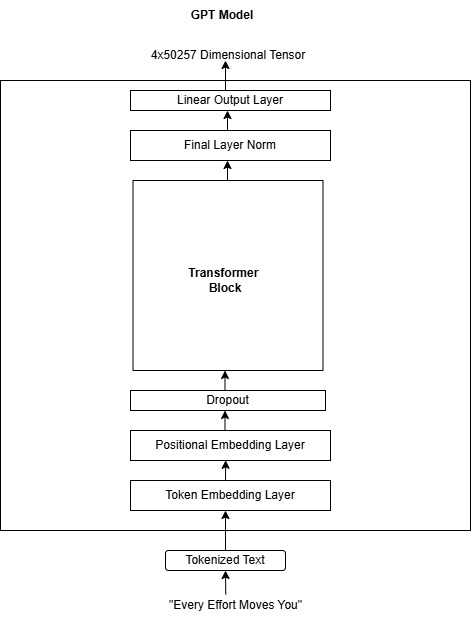

In [24]:
import torch
import torch.nn as nn

In [25]:
class DummyGPTModel(nn.Module):

    def __init__(self,cfg):

        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(*[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]) # is equivalent to nn.Sequential(block1, block2, block3,...,blockn)
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"],cfg["vocab_size"],bias = False)

    def forward(self,in_idx):

        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len)) #This acts like a lookup table  
        x = tok_embeds + pos_embeds
        x  = self.drop_emb(x)
        x = self.final_norm(x)
        logits = self.out_head(x)

        return logits
        

In [26]:
class DummyTransformerBlock(nn.Module): #A simple placeholder class containing Dummy Transformer Block

    def __init__(self,cfg):

        super().__init__()

    def forward(self,x): #Just return the input as it is

        return x 

In [27]:
class DummyLayerNorm(nn.Module): #

    def __init__(self,normalized_shape, eps = 1e-5):

        super().__init__()

    def forward(self,x):

        return x

In [28]:
torch.arange(4)

tensor([0, 1, 2, 3])

In [29]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

In [30]:
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))

batch = torch.stack(batch,dim=0) #Why this ??? -> To convert it into a rowwise tensor
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [31]:
#Initializing the Dummy GPT Model and feeding it the tokenized batch

torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print(f"Output Shape: {logits.shape}")
print(logits)

Output Shape: torch.Size([2, 4, 50257])
tensor([[[-1.4271, -0.2840,  1.5161,  ...,  0.7439, -0.6418,  0.4433],
         [-0.2277, -2.2575, -1.9347,  ...,  0.2742, -0.9795,  1.7535],
         [ 0.9470, -1.8268, -1.0140,  ..., -0.3285,  1.5704,  0.2225],
         [ 0.3692,  1.1697, -0.4005,  ..., -0.1971, -0.4948,  0.4396]],

        [[-0.7591, -1.3767,  1.9161,  ...,  0.8532,  0.2496,  0.9997],
         [ 0.2858, -1.2932, -1.5919,  ...,  0.8678, -0.5365,  2.1935],
         [ 1.5425, -0.5500, -0.6527,  ..., -0.6807, -0.3069,  0.0805],
         [ 1.1016,  0.7336,  0.2600,  ..., -0.2363, -0.4450,  0.5277]]],
       grad_fn=<UnsafeViewBackward0>)
